In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataset import uciDataset, get_dataloader
from diffusion import Diffusion
import torch
from tqdm import tqdm
from mlp import ScoreModel
import gpytorch

# GP with inducing points

In [129]:
dataset = uciDataset("elevators", x_normalise=True, y_normalise=True)
train_loader, val_loader, test_loader = get_dataloader(dataset, batch_size=64, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)

print(dataset.X.dtype, dataset.X.shape)
print(dataset.y.dtype, dataset.y.shape)

torch.float32 torch.Size([16599, 18])
torch.float32 torch.Size([16599])


In [130]:
class DiffusionGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_dist = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_dist, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        input_size = inducing_points.size(1)
        x_dims = input_size - 2  # Last 2 dims are for t and y_t
        
        # Same kernel: product over x, t, y_t
        self.mean_module = gpytorch.means.LinearMean(input_size=input_size)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.ProductKernel(
                gpytorch.kernels.MaternKernel(nu=1.5, active_dims=list(range(x_dims))),  # x
                gpytorch.kernels.MaternKernel(nu=0.5, active_dims=[x_dims]),  # t
                gpytorch.kernels.MaternKernel(nu=0.5, active_dims=[x_dims + 1]),   # y_t
            ), 
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [131]:
num_epochs = 200
time_steps = 1000
epoch_update = 10
total_dim = dataset.X.shape[1] + 2
loss_type = "mse"
num_inducing_points = 800
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# initialise model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
inducing_points = torch.rand(num_inducing_points, total_dim).to(device)
model = DiffusionGP(inducing_points).to(device)
likelihood = likelihood.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
diffusion = Diffusion(T=time_steps, device=device)


best_val_loss = float('inf')
train_losses = []
val_losses = []
if loss_type == "elbo":
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_loader.dataset))
elif loss_type == "mse":
    mll = torch.nn.MSELoss()

# training loop
model.train()
likelihood.train()
for epoch in range(num_epochs):
    train_epoch_loss = 0
    train_num_batches = 0

    for batch in train_loader:
        x = batch['X'].to(device)
        y_0 = batch['y'].to(device)
        t = torch.randint(1, time_steps, (x.shape[0],), device=device)
        noise = torch.randn_like(y_0, device=device)
        y_t = diffusion.q_sample(y_0, t, noise)
        t = t / time_steps # normalise time step

        # Stack x, t, y_t
        t = t.unsqueeze(1)
        if y_t.dim() == 1:
            y_t = y_t.unsqueeze(1)
        z = torch.cat([x, t, y_t], dim=1)

        # Forward pass
        output = model(z)
        if loss_type == "elbo":
            loss = -mll(output, noise)
        elif loss_type == "mse":
            loss = mll(output.mean, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
        train_num_batches += 1
        
    train_losses.append(train_epoch_loss / train_num_batches)

    # Validation phase
    model.eval()
    likelihood.eval()
    val_epoch_loss = 0
    val_num_batches = 0
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for batch in val_loader:
            x = batch['X'].to(device)
            y_0 = batch['y'].to(device)
            t = torch.randint(1, time_steps, (x.shape[0],), device=device)
            noise = torch.randn_like(y_0, device=device)
            y_t = diffusion.q_sample(y_0, t, noise)
            t = t / time_steps # normalise time step
        
            # Stack x, t, y_t
            t = t.unsqueeze(1)
            if y_t.dim() == 1:
                y_t = y_t.unsqueeze(1)
            z = torch.cat([x, t, y_t], dim=1)

            # Forward pass
            output = model(z)
            if loss_type == "elbo":
                loss = -mll(output, noise)
            elif loss_type == "mse":
                loss = mll(output.mean, noise)
            val_epoch_loss += loss.item()
            val_num_batches += 1
    val_losses.append(val_epoch_loss / val_num_batches)
    
    if epoch % epoch_update == 0:
        print(f'Epoch {epoch}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

Epoch 0/200, Train Loss: 5.3064, Val Loss: 2.7469
Epoch 10/200, Train Loss: 0.3257, Val Loss: 0.5667
Epoch 20/200, Train Loss: 0.2593, Val Loss: 0.2875
Epoch 30/200, Train Loss: 0.3053, Val Loss: 0.2578
Epoch 40/200, Train Loss: 0.2819, Val Loss: 0.2692
Epoch 50/200, Train Loss: 0.2919, Val Loss: 0.2576
Epoch 60/200, Train Loss: 0.2477, Val Loss: 0.2583
Epoch 70/200, Train Loss: 0.2509, Val Loss: 0.2584
Epoch 80/200, Train Loss: 0.2475, Val Loss: 0.2286
Epoch 90/200, Train Loss: 0.2562, Val Loss: 0.2594
Epoch 100/200, Train Loss: 0.2496, Val Loss: 0.2377
Epoch 110/200, Train Loss: 0.2655, Val Loss: 0.2557
Epoch 120/200, Train Loss: 0.2498, Val Loss: 0.2510
Epoch 130/200, Train Loss: 0.2577, Val Loss: 0.2319
Epoch 140/200, Train Loss: 0.2605, Val Loss: 0.2757
Epoch 150/200, Train Loss: 0.2637, Val Loss: 0.2813
Epoch 160/200, Train Loss: 0.2463, Val Loss: 0.2452
Epoch 170/200, Train Loss: 0.2367, Val Loss: 0.2393
Epoch 180/200, Train Loss: 0.2509, Val Loss: 0.2438
Epoch 190/200, Train Lo

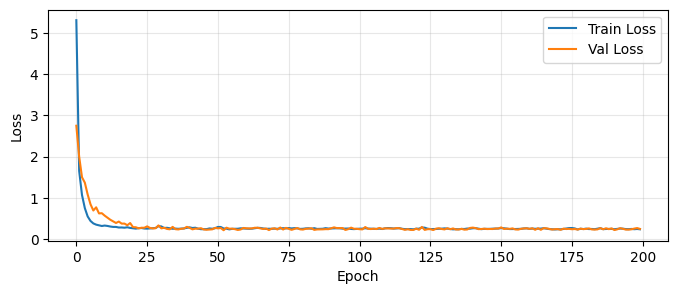

In [132]:
plt.figure(figsize=(8, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
# plt.ylim(0.5,2)
plt.legend()
plt.show()

In [133]:
time_steps = 1000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# average test loss
test_loss = 0
predictions = []
true_values = []

with tqdm(total=len(test_loader)) as pbar:
    for batch in test_loader:
        x = batch['X'].to(device)
        y_0 = batch['y'].to(device)
        y_t = torch.randn_like(y_0, device=device)

        model.eval()
        likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            for t in range(time_steps-1, -1, -1):
                t_tensor = torch.ones_like(y_t) * (t+1)
                t_tensor = t_tensor / time_steps

                # Stack x, t, y_t   
                if y_t.dim() == 1:
                    y_t = y_t.unsqueeze(1)
                if t_tensor.dim() == 1:
                    t_tensor = t_tensor.unsqueeze(1)
                z = torch.cat([x, t_tensor, y_t], dim=1)
                score = model(z).mean
                y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score.unsqueeze(1))
                y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])

        predictions.append(y_t)
        true_values.append(y_0)
        pbar.update(1)

predictions = torch.cat(predictions, dim=0).flatten()
true_values = torch.cat(true_values, dim=0)

100%|██████████| 26/26 [00:38<00:00,  1.49s/it]


In [134]:
rmse = torch.sqrt(torch.mean((true_values - predictions)**2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.5730


In [135]:
# scale the predictions and true values
y_scaler = dataset.y_scaler
predictions_scaled = y_scaler.inverse_transform(predictions.reshape(-1,1))
true_values_scaled = y_scaler.inverse_transform(true_values.reshape(-1,1))

/var/folders/sq/_ygl92r55ks2__x_h38qg7h00000gn/T/ipykernel_5800/4132184227.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


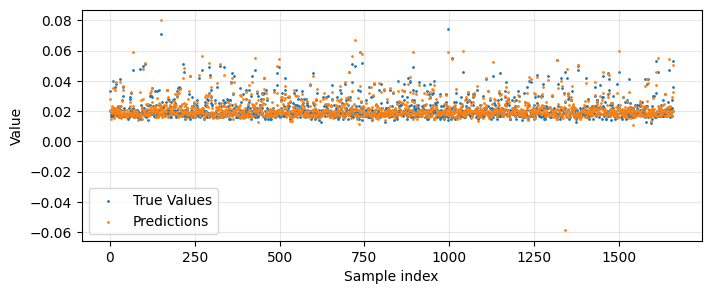

In [136]:
plt.figure(figsize=(8, 3))
plt.grid(alpha=0.3)
# plt.ylim(0.5,2)
plt.legend()
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.scatter(range(len(true_values_scaled)), true_values_scaled,s=1, label='True Values')
plt.scatter(range(len(predictions_scaled)), predictions_scaled,s=1, label='Predictions')
plt.legend()
plt.show()

# SGD GP

In [2]:
dataset = uciDataset("elevators", x_normalise=True, y_normalise=True)
print(dataset.X.dtype, dataset.X.shape)
print(dataset.y.dtype, dataset.y.shape)

torch.float32 torch.Size([16599, 18])
torch.float32 torch.Size([16599])


In [3]:
# augment dataset
T = 1000
d = Diffusion(T=T)
augmented_X = torch.empty((len(dataset)*(T-1), dataset.X.shape[1] + 2))
augmented_y = torch.empty((len(dataset)*(T-1), 1))

with tqdm(total=len(dataset)*(T-1)) as pbar:
    for i in range(len(dataset)):
        x = dataset.X[i]
        y = dataset.y[i].unsqueeze(0)
        for t in range(1, T):
            noise = torch.randn(1)
            y_t = d.q_sample(y, t, noise)
            augmented_X[i*(T-1)+t-1] = torch.cat([x, torch.tensor([t]), y_t], dim=0)
            augmented_y[i*(T-1)+t-1] = noise
            pbar.update(1)

print(augmented_X.shape, augmented_y.shape)

  0%|          | 0/16582401 [00:00<?, ?it/s]

100%|██████████| 16582401/16582401 [05:05<00:00, 54315.22it/s]

torch.Size([16582401, 20]) torch.Size([16582401, 1])


In [5]:
# save augmented dataset
torch.save(augmented_X, "augmented_X.pt")
torch.save(augmented_y, "augmented_y.pt")

In [3]:
# load augmented dataset
augmented_X = torch.load("augmented_X.pt")
augmented_y = torch.load("augmented_y.pt")

print(augmented_X.shape, augmented_y.shape)

torch.Size([16582401, 20]) torch.Size([16582401, 1])


In [4]:
from aug_dataset import augDataset, aug_dataloader

aug_dataset = augDataset(augmented_X, augmented_y, x_normalise=False, y_normalise=False)
train_loader, val_loader, test_loader = aug_dataloader(aug_dataset, batch_size=64, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
len(train_loader)

/Users/gloriasun/Documents/GitHub/Diffusion-Gaussian-Processes/uci/aug_dataset.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.X, dtype=torch.float32)
/Users/gloriasun/Documents/GitHub/Diffusion-Gaussian-Processes/uci/aug_dataset.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.float32)


207280

In [6]:
def matern32_kernel(a, b, lengthscale):
    """Standard scalar/vector Matern 3/2 kernel."""
    a = a / lengthscale
    b = b / lengthscale
    dists = np.linalg.norm(a[:, None] - b[None, :], axis=-1)
    sqrt3_d = np.sqrt(3) * dists
    return (1 + sqrt3_d) * np.exp(-sqrt3_d)

def composite_kernel(X1, X2, x_dims):
    """
    Product of 3 Matérn 3/2 kernels applied to:
    - X1[:, :x_dims] and X2[:, :x_dims] → input features
    - X1[:, x_dims] and X2[:, x_dims]   → diffusion time t
    - X1[:, x_dims+1] and X2[:, x_dims+1] → noisy target y_t
    """
    k_x = matern32_kernel(X1[:, :x_dims], X2[:, :x_dims], lengthscale=0.7)
    k_t = matern32_kernel(X1[:, x_dims:x_dims+1], X2[:, x_dims:x_dims+1], lengthscale=1.0)
    k_y = matern32_kernel(X1[:, x_dims+1:], X2[:, x_dims+1:], lengthscale=1.0)
    
    return 1.2**2 * k_x * k_t * k_y  # signal scale on the whole product

In [ ]:
lr = 0.001
momentum = 0.9
polyak = 1e-2
iterations = 1
B = 32
N = len(augmented_X)
noise_scale = 1.2

alpha = np.zeros((N,))
alpha_polyak = np.zeros((N,))
v = np.zeros((N,))

def g(params, idx):
    K_batch = composite_kernel(augmented_X[idx], augmented_X, x_dims=18)
    grad = np.zeros((N,))
    grad[idx] = K_batch @ params - augmented_y[idx] + (noise_scale ** 2) * params[idx]
    return (N / B) * grad

def update(params, params_polyak, velocity, idx):
    grad = g(params, idx)
    velocity = momentum * velocity - lr * grad
    params = params + velocity
    params_polyak = polyak * params + (1.0 - polyak) * params_polyak
    return params, params_polyak, velocity

for i in range(iterations):
    idx = np.random.choice(N, size=(B,), replace=False)
    alpha, alpha_polyak, v = update(alpha, alpha_polyak, v, idx)
